<a href="https://colab.research.google.com/github/zeldaamth/Jakarta-House-Price-Prediction-Random-Forest-CRISP-DM/blob/main/CRISP_DM_ZeldaMeutiaSaid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Business Understanding**

**Permasalahan Nyata**

Di era ini, seperti diketahui banyak Generasi Z (Gen Z) yang mengalami ketidakmampuan untuk membeli rumah karena adanya kesenjangan pendapatan dan harga properti yang tinggi. Hal ini tentunya juga berdampak kepada pelaku industri properti (agen real estate, developer, dan individu penjual) di Jakarta, mereka menghadapi masalah:

1. Tingginya ketidakakuratan dalam penentuan harga jual rumah
2. Proses valuasi (penilaian harga) sering tidak objektif dan memakan waktu karena:
- Tidak ada sistem estimasi harga yang terstandarisasi
- Penentuan harga masih mengandalkan intuisi atau perbandingan manual yang terbatas

**Dampak:**

- Overpricing (Harga terlalu tinggi): Rumah menjadi tidak laku selama berbulan-bulan, menyebabkan biaya pemeliharaan menumpuk dan kehilangan momentum penjualan.
- Underpricing (Harga terlalu rendah): Kerugian finansial yang signifikan bagi penjual atau kurangnya margin keuntungan bagi developer.
- Inefisiensi waktu negosiasi dan menurunnya kepercayaan klien terhadap agen properti.


**Formulasi Data Mining**

Berdasarkan karakteristik dataset yang tersedia (district, city, bed_rooms, bath_rooms, carport, land_area, building_area), terdapat beberapa pendekatan yang dapat dipertimbangkan:

- Regresi — Memprediksi harga jual rumah secara langsung (dalam Rupiah) berdasarkan fitur fisik dan lokasi.
- Klasifikasi — Menentukan apakah sebuah rumah masuk kategori tertentu (misalnya "Premium" atau "Standar") berdasarkan kombinasi fitur yang ada.
- Clustering — Mengelompokkan tipe-tipe rumah berdasarkan kesamaan karakteristik (misalnya klaster "Rumah Mewah Sentral", "Rumah Menengah Pinggiran") tanpa label sebelumnya.


**Pendekatan**

Berkaitan dengan kebutuhan utama stakeholder yang memerlukan angka estimasi harga dalam Rupiah sebagai dasar transaksi jual-beli, pengajuan KPR ke bank, atau pelaporan aset keuangan, maka pendekatan yang dipilih adalah Regresi menggunakan algoritma Random Forest Regressor.

Alasan pemilihan:
- Output berupa nilai numerik langsung dapat digunakan sebagai acuan harga oleh agen, developer, maupun bank — lebih actionable dibanding label kategori.
- Label seperti "Mahal" atau "Murah" pada klasifikasi terlalu relatif di pasar Jakarta yang memiliki rentang harga dari ratusan juta hingga ratusan miliar.

Maka dari itu, Random Forest Regressor dipilih karena mampu menangkap hubungan non-linear antara fitur lokasi/fisik dan harga, serta tahan terhadap outlier yang signifikan pada dataset ini.


**Kriteria Sukses**
- R² (R-Squared) ≥ 0.75 — Model dianggap layak jika mampu menjelaskan minimal 75% variansi harga, mengindikasikan bahwa fitur fisik dan lokasi yang tersedia memang cukup informatif untuk estimasi harga.
- MAE (Mean Absolute Error) ≤ Rp 2,5 Miliar — Mengganti metrik persentase (MAPE) karena sifat data harga yang sangat heterogen (mulai ratusan juta hingga puluh miliar) menyebabkan perhitungan persentase menjadi bias (MAPE Trap). Dengan toleransi maksimal Rp 2,5 Miliar, estimasi harga masih dalam rentang yang realistis dan dapat dijadikan dasar negosiasi awal oleh agen properti.
- Fitur Lokasi masuk dalam 3 besar pengaruh. Fitur district dan city memberikan kontribusi signifikan pada Feature Importance, membuktikan bahwa model peka dan mampu mencerminkan perbedaan harga antar wilayah, walaupun mungkin bukan fitur nomor satu.

# **Data Understanding**
Step:

1. Load Data
2. Struktur, Tipe Data, Deskripsi & rentang nilai
3. Statistik Deskriptif
4. Distribusi Target
5. Missing Value
6. Korelasi

In [ ]:
!pip install category_encoders

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Supaya grafik tampil rapi
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

In [ ]:
#Load dan Struktur Data

import pandas as pd

file_path = '/content/drive/MyDrive/jakarta_house.csv'

df = pd.read_csv(file_path, encoding='latin1')
df.head()

,index,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,1,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,3,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,4,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,5,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


In [ ]:
# Struktur dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          10000 non-null  int64  
 1   price          10000 non-null  int64  
 2   district       10000 non-null  object 
 3   city           10000 non-null  object 
 4   bed_rooms      10000 non-null  int64  
 5   bath_rooms     10000 non-null  int64  
 6   carport        10000 non-null  int64  
 7   land_area      9997 non-null   float64
 8   building_area  9995 non-null   float64
dtypes: float64(2), int64(5), object(2)
memory usage: 703.3+ KB


Temuan:
- Missing value sangat minim (hanya pada fitur luas tanah dan bangunan)
- Tipe data terdiri dari kategorikal dan numerik
- Tidak semua fiturnya relevan

In [ ]:
#Statistik Deskriptif
df.describe()

,index,price,bed_rooms,bath_rooms,carport,land_area,building_area
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,9997.000000,9995.000000
mean,5000.50000,1.004029e+10,4.253500,3.521300,1.578900,296.610183,319.962481
std,2886.89568,2.004519e+10,3.176609,2.900136,1.743467,502.921686,357.676034
min,1.00000,1.850000e+06,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2500.75000,2.500000e+09,3.000000,2.000000,1.000000,100.000000,139.000000
50%,5000.50000,4.500000e+09,4.000000,3.000000,1.000000,177.000000,230.000000
75%,7500.25000,9.800000e+09,5.000000,4.000000,2.000000,335.000000,400.000000
max,10000.00000,9.000000e+11,63.000000,63.000000,31.000000,17714.000000,15331.000000


**Temuan:**

- Harga rumah memiliki rentang yang sangat lebar, mulai dari sekitar Rp1,85 juta hingga Rp900 miliar, yang menunjukkan adanya variasi harga yang tinggi.
- Rata-rata harga lebih besar daripada median sehingga mengindikasikan distribusi harga bersifat right-skewed.
- Variabel land_area dan building_area juga memiliki nilai maksimum yang jauh di atas mayoritas data sehingga berpotensi mengandung outlier.

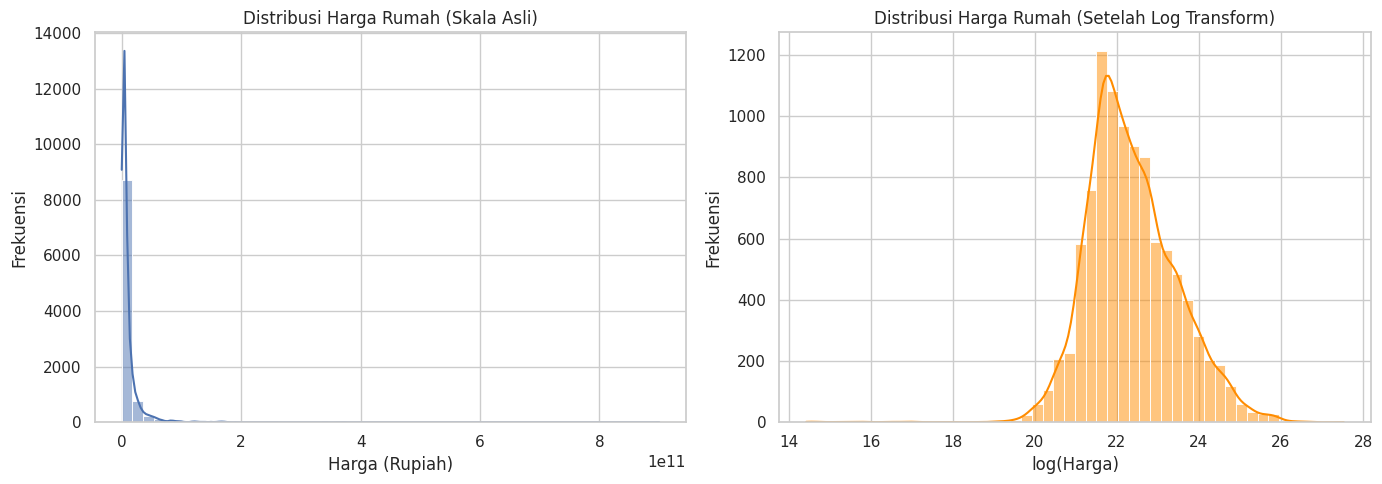

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi harga asli
axes[0].set_title('Distribusi Harga Rumah (Skala Asli)')
sns.histplot(df['price'], kde=True, bins=50, ax=axes[0])
axes[0].set_xlabel('Harga (Rupiah)')
axes[0].set_ylabel('Frekuensi')

# Distribusi harga setelah log transform (preview)
axes[1].set_title('Distribusi Harga Rumah (Setelah Log Transform)')
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='darkorange', ax=axes[1])
axes[1].set_xlabel('log(Harga)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

Temuan:

Distribusi harga rumah bersifat right-skewed, di mana sebagian besar rumah berada pada rentang harga rendah hingga menengah, sementara hanya sedikit rumah yang memiliki harga sangat tinggi. Kondisi ini menunjukkan perlunya penanganan outlier atau transformasi data sebelum proses pemodelan.

/tmp/ipykernel_1115/2606649807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='city', y='price', palette='Set2')


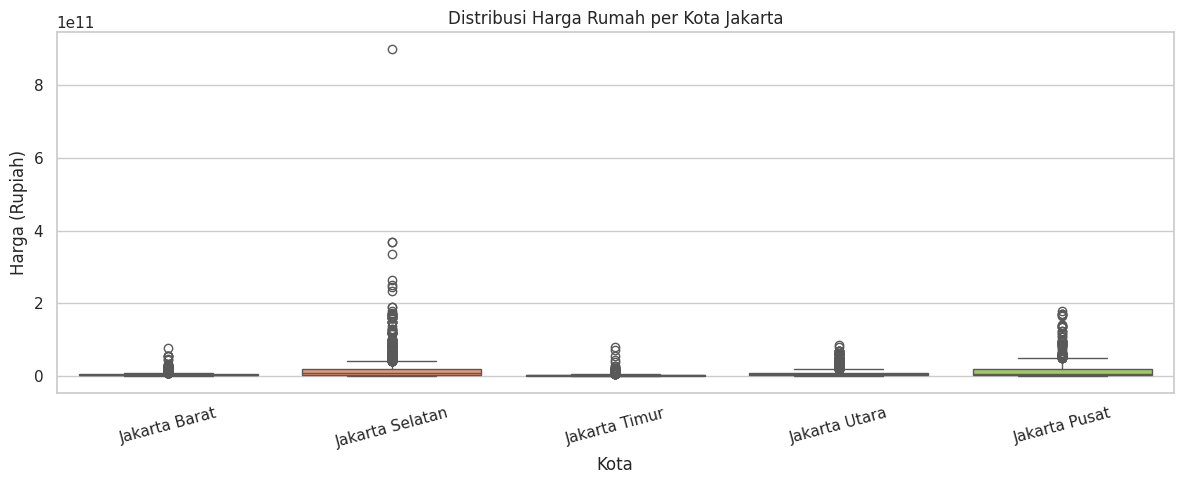

Harga rata-rata per kota:
city
Jakarta Pusat      Rp 19,758,250,877
Jakarta Selatan    Rp 16,704,478,070
Jakarta Utara       Rp 8,592,812,593
Jakarta Barat       Rp 4,523,864,264
Jakarta Timur       Rp 3,486,267,929
Name: price, dtype: object


In [ ]:
# Distribusi harga per kota
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='city', y='price', palette='Set2')
plt.xticks(rotation=15)
plt.title('Distribusi Harga Rumah per Kota Jakarta')
plt.xlabel('Kota')
plt.ylabel('Harga (Rupiah)')
plt.tight_layout()
plt.show()

# Harga rata-rata per kota
print("Harga rata-rata per kota:")
print(df.groupby('city')['price'].mean().sort_values(ascending=False)
        .apply(lambda x: f"Rp {x:,.0f}"))

Temuan:

Distribusi harga rumah menunjukkan bahwa Jakarta Pusat memiliki rata-rata harga rumah tertinggi, diikuti oleh Jakarta Selatan, Jakarta Utara, Jakarta Barat, dan Jakarta Timur, dengan variasi harga yang cukup besar terutama di Jakarta Selatan dan Jakarta Pusat.

/tmp/ipykernel_1115/2915494072.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_districts.values, y=top_districts.index, palette='Blues_r')


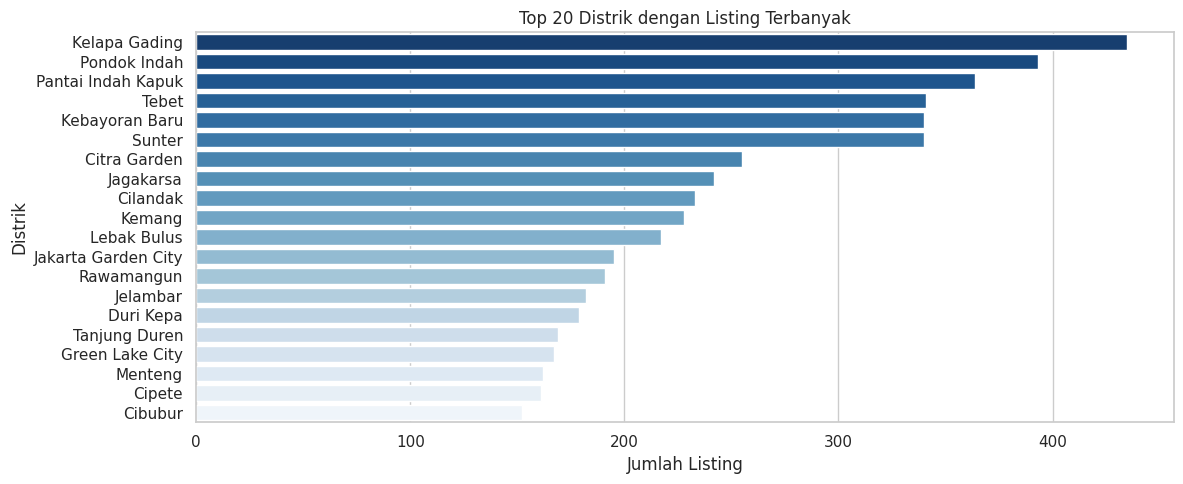

In [ ]:
# Menampilkan top 20 district terbanyak
top_districts = df['district'].value_counts().head(20)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_districts.values, y=top_districts.index, palette='Blues_r')
plt.title('Top 20 Distrik dengan Listing Terbanyak')
plt.xlabel('Jumlah Listing')
plt.ylabel('Distrik')
plt.tight_layout()
plt.show()

Temuan:

Distribusi listing rumah terkonsentrasi pada beberapa distrik, dengan Kelapa Gading memiliki jumlah listing terbanyak, diikuti Pondok Indah, Pantai Indah Kapuk, Tebet, dan Sunter. Hasil ini menunjukkan bahwa aktivitas pasar properti lebih tinggi pada distrik-distrik tersebut.

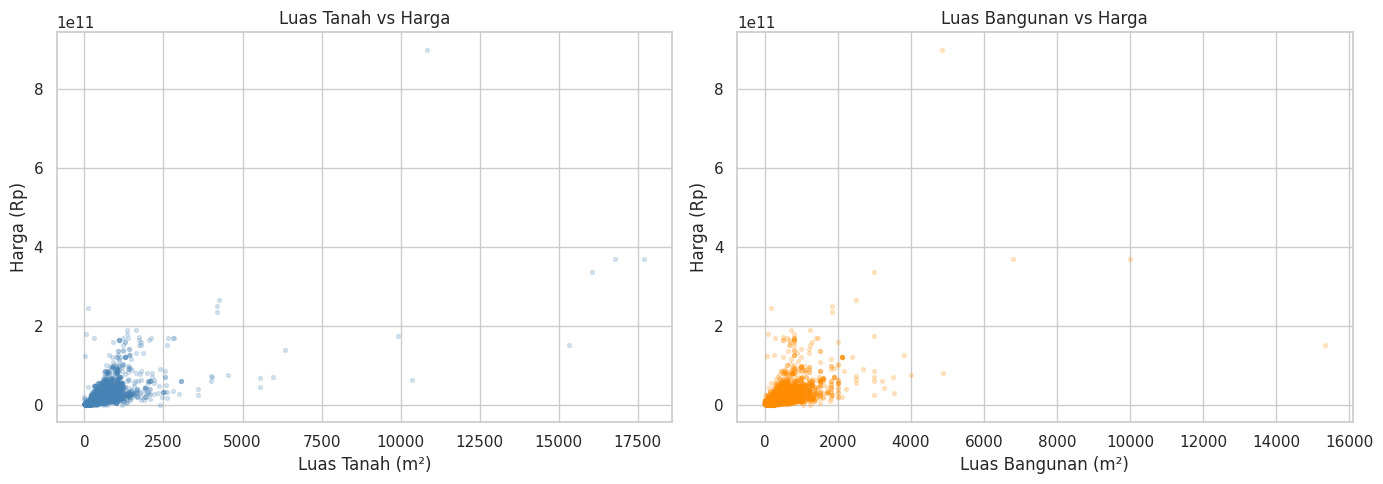

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title('Luas Tanah vs Harga')
axes[0].scatter(df['land_area'], df['price'], alpha=0.2, s=8, color='steelblue')
axes[0].set_xlabel('Luas Tanah (m²)')
axes[0].set_ylabel('Harga (Rp)')

axes[1].set_title('Luas Bangunan vs Harga')
axes[1].scatter(df['building_area'], df['price'], alpha=0.2, s=8, color='darkorange')
axes[1].set_xlabel('Luas Bangunan (m²)')
axes[1].set_ylabel('Harga (Rp)')

plt.tight_layout()
plt.show()

Temuan:

Luas tanah dan luas bangunan menunjukkan hubungan positif terhadap harga rumah, di mana harga cenderung meningkat seiring bertambahnya ukuran properti.
Hubungan tersebut tidak sepenuhnya linear dan terdapat beberapa outlier pada properti berukuran sangat besar, sehingga algoritma berbasis pohon seperti Random Forest lebih sesuai digunakan.

In [ ]:
#Missing Value
df.isnull().sum()

,0
index,0
price,0
district,0
city,0
bed_rooms,0
bath_rooms,0
carport,0
land_area,3
building_area,5


Temuan:
- Missing value hanya ditemukan pada land_area sebanyak 3 data dan building_area sebanyak 5 data.

Jumlah tersebut sangat kecil sehingga dapat ditangani menggunakan imputasi median tanpa memengaruhi kualitas dataset secara signifikan.

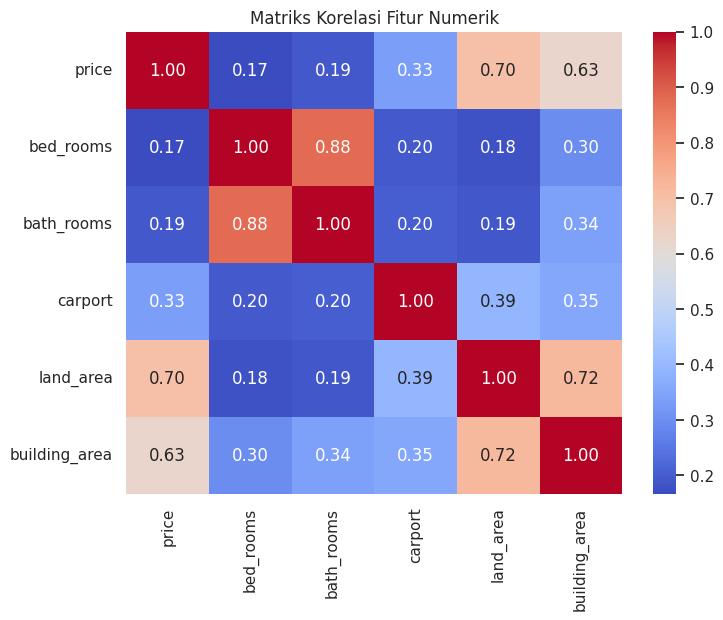

In [ ]:
# Step 6: Korelasi
numerical_cols = ['price', 'bed_rooms', 'bath_rooms', 'carport', 'land_area', 'building_area']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

Temuan:
- Building_area dan land_area memiliki korelasi positif yang cukup kuat terhadap harga rumah, sehingga keduanya diperkirakan menjadi faktor utama dalam prediksi harga.
- Bed_rooms dan bath_rooms memiliki korelasi sangat tinggi satu sama lain, yang menunjukkan adanya hubungan erat antara kedua variabel tersebut.
- Fitur lokasi (district/city) tidak terlihat pengaruhnya karena belum berbentuk numerik

In [ ]:
#Verifikasi Kualitas Data
print("=" * 55)
print("   VERIFIKASI KUALITAS DATA")
print("=" * 55)

# 1. Pseudo-missing value
pseudo_bed  = len(df[df['bed_rooms']  == 0])
pseudo_bath = len(df[df['bath_rooms'] == 0])
print(f"\n1. Anomali Logis (Nilai 0 tidak realistis):")
print(f"   - bed_rooms  = 0 : {pseudo_bed} baris")
print(f"   - bath_rooms = 0 : {pseudo_bath} baris")

# 2. Outlier harga
print(f"\n2. Top 5 Harga Termahal:")
print(df.nlargest(5, 'price')[['district','city','land_area','price']].to_string(index=False))

# 3. Outlier fisik
print(f"\n3. Top 5 Luas Tanah Terbesar:")
print(df.nlargest(5, 'land_area')[['district','land_area','building_area','price']].to_string(index=False))

# 4. Multikolinearitas
corr_val = df['bed_rooms'].corr(df['bath_rooms'])
print(f"\n4. Korelasi bed_rooms vs bath_rooms: {corr_val:.2f}")

print("\n" + "=" * 55)

   VERIFIKASI KUALITAS DATA

1. Anomali Logis (Nilai 0 tidak realistis):
   - bed_rooms  = 0 : 198 baris
   - bath_rooms = 0 : 198 baris

2. Top 5 Harga Termahal:
     district            city  land_area        price
 Pondok Indah Jakarta Selatan    10847.0 900000000000
    Kebagusan Jakarta Selatan    17714.0 370000000000
TB Simatupang Jakarta Selatan    16791.0 370000000000
Lenteng Agung Jakarta Selatan    16057.0 337000000000
 Pondok Indah Jakarta Selatan     4260.0 265000000000

3. Top 5 Luas Tanah Terbesar:
     district  land_area  building_area        price
    Kebagusan    17714.0         6800.0 370000000000
TB Simatupang    16791.0        10000.0 370000000000
Lenteng Agung    16057.0         3000.0 337000000000
     Kalibata    15331.0        15331.0 150000000000
 Pondok Indah    10847.0         4850.0 900000000000

4. Korelasi bed_rooms vs bath_rooms: 0.88



Temuan:
- Ditemukan pseudo-missing value berupa rumah dengan bed_rooms dan bath_rooms bernilai nol yang secara logis tidak merepresentasikan rumah tinggal normal.
- Selain itu, terdapat outlier pada harga maupun ukuran properti yang perlu ditangani sebelum proses pemodelan untuk meningkatkan kualitas model.

## **Kesimpulan**

## Identifikasi Kendala

1. Missing Value
- Terdapat 3 nilai kosong pada land_area dan 5 pada building_area
2. Anomali Logis (Pseudo-Missing)
- Ditemukan 198 baris dengan jumlah kamar tidur dan kamar mandi bernilai 0 (tidak realistis untuk rumah tinggal)
3. Outlier Ekstrem
- Terdapat aset dengan harga hingga 900 Miliar dan luas tanah 17.714 m2 (sudah masuk kategori estate/kavling, bukan rumah tinggal standar)
4. Distribusi Target Tidak Normal
- Harga rumah sangat right-skewed (mayoritas murah, sedikit sangat mahal) → berpotensi membuat model bias


# Karakteristik Data dan Alasan Pemilihan Algoritma
Berdasarkan seluruh hasil ekplorasi kode di atas, dapat disimpulkan bahwa dataset ini memiliki karakteristik sebagai berikut:

1. Campuran Tipe Data: Terdiri dari fitur numerik (luas, jumlah kamar) dan kategorikal tingkat tinggi (lebih dari 100 unique value pada kolom district).
2. Distribusi Target Ekstrem: Histogram dan statistik deskriptif (mean 10 Miliar vs median 4,5 Miliar) membuktikan variabel price sangat right-skewed.
3. Kualitas Data Bermasalah: Terdapat outlier ekstrem (harga 900 Miliar, luas tanah 17.714 m2), pseudo-missing value (198 data dengan 0 kamar), dan multikolinearitas tinggi (korelasi 0.88 antara kamar tidur dan mandi).
4. Pola Hubungan Non-Linear: Pengaruh lokasi (misal: Pondok Indah vs Cakung) terhadap harga tidak bisa diukur dengan garis lurus (linear).

## Algoritma yang Dipilih: Random Forest Regressor
Kelebihan:

1. Mampu menangani outlier lebih baik
2. Dapat menangkap hubungan non-linear
3. Dapat menangani interaksi antar variabel
4. Tidak membutuhkan asumsi normalitas
5. Tidak sensitif terhadap multikolinearitas
6. Menyediakan feature importance

Kekurangan:

1. Interpretasi lebih sulit dibanding regresi linear
2. Training lebih lambat


# **Data Preparation**

In [ ]:
# Menghapus kolom tidak relevan (kolom index)
df = df.drop(columns=['index'])
print(f"Kolom tersisa: {list(df.columns)}")

Kolom tersisa: ['price', 'district', 'city', 'bed_rooms', 'bath_rooms', 'carport', 'land_area', 'building_area']


Temuan:
- Kolom index berhasil dihapus karena hanya berfungsi sebagai penomoran data dan tidak mengandung informasi yang relevan terhadap prediksi harga rumah.
- Setelah proses ini, dataset terdiri dari delapan fitur utama, yaitu price, district, city, bed_rooms, bath_rooms, carport, land_area, dan building_area, yang akan digunakan pada tahap analisis dan pemodelan selanjutnya.

In [ ]:
# Menangani missing values
df['land_area']     = df['land_area'].fillna(df['land_area'].median())
df['building_area'] = df['building_area'].fillna(df['building_area'].median())

print("Missing value setelah imputasi:")
print(df[['land_area', 'building_area']].isnull().sum())

Missing value setelah imputasi:
land_area        0
building_area    0
dtype: int64


Temuan:
- Seluruh missing value pada variabel land_area dan building_area berhasil ditangani menggunakan metode imputasi median, sehingga tidak ada lagi nilai yang hilang dalam dataset

In [ ]:
# Mengimputasi Pseudo-Missing Value (nilai 0 → median)
median_br   = df.loc[df['bed_rooms']  > 0, 'bed_rooms'].median()
median_bath = df.loc[df['bath_rooms'] > 0, 'bath_rooms'].median()

df['bed_rooms']  = df['bed_rooms'].replace(0, median_br)
df['bath_rooms'] = df['bath_rooms'].replace(0, median_bath)

print(f"Median bed_rooms  (non-zero): {median_br}")
print(f"Median bath_rooms (non-zero): {median_bath}")
print(f"Nilai 0 tersisa pada bed_rooms : {(df['bed_rooms']==0).sum()}")
print(f"Nilai 0 tersisa pada bath_rooms: {(df['bath_rooms']==0).sum()}")

Median bed_rooms  (non-zero): 4.0
Median bath_rooms (non-zero): 3.0
Nilai 0 tersisa pada bed_rooms : 0
Nilai 0 tersisa pada bath_rooms: 0


Temuan:

Nilai pseudo-missing pada variabel bed_rooms dan bath_rooms, yang ditandai dengan nilai 0, berhasil ditangani menggunakan imputasi median dari data yang bernilai lebih dari 0. Median jumlah kamar tidur sebesar 4 dan kamar mandi sebesar 3 digunakan sebagai nilai pengganti, sehingga tidak terdapat lagi nilai 0 pada kedua variabel.

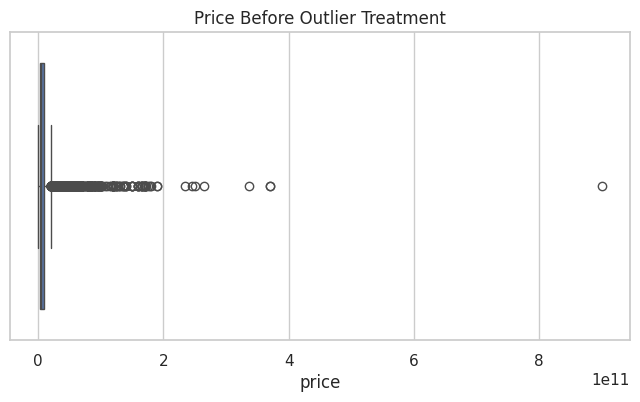

In [ ]:
# Visualisasi Sebelum Outlier Capping
plt.figure(figsize=(8,4))
sns.boxplot(x=df['price'])
plt.title("Price Before Outlier Treatment")
plt.show()

Temuan:

Boxplot menunjukkan bahwa variabel price mengandung banyak outlier, terutama pada nilai harga yang sangat tinggi. Sebagian besar data terkonsentrasi pada rentang harga yang lebih rendah, sementara terdapat beberapa properti dengan harga mencapai ratusan miliar rupiah yang berada jauh di luar sebaran utama.

In [ ]:
#  Capping Outlier Harga (Persentil 99)
price_before = len(df)
price_cap    = df['price'].quantile(0.99)

df = df[df['price'] <= price_cap].copy()

print(f"Price cap (persentil 99): Rp {price_cap:,.0f}")
print(f"Jumlah data sebelum capping: {price_before}")
print(f"Jumlah data setelah capping : {len(df)}")
print(f"Baris dihapus               : {price_before - len(df)}")

Price cap (persentil 99): Rp 85,000,000,000
Jumlah data sebelum capping: 10000
Jumlah data setelah capping : 9904
Baris dihapus               : 96


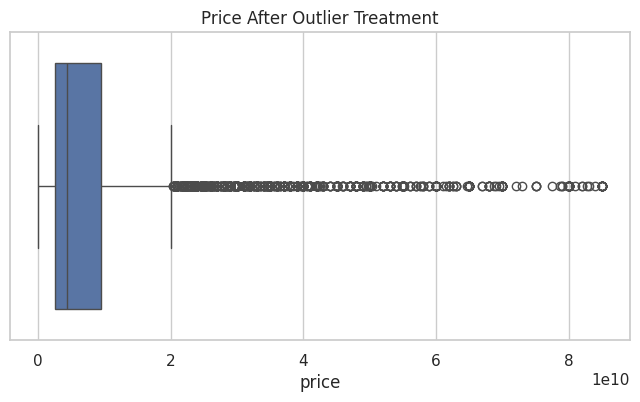

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['price'])
plt.title("Price After Outlier Treatment")
plt.show()

Temuan:

Setelah dilakukan outlier capping, nilai harga rumah yang sangat ekstrem berhasil dibatasi sehingga rentang distribusi harga menjadi lebih terkendali.

In [ ]:
# Mengatasi Right-Skewed (Log Transformation pada Target (price))
df['price_log'] = np.log1p(df['price'])

print("Statistik price_log:")
print(df['price_log'].describe().round(4))

Statistik price_log:
count    9904.0000
mean       22.3211
std         1.0448
min        14.4307
25%        21.6396
50%        22.2049
75%        22.9746
max        25.1659
Name: price_log, dtype: float64


Temuan:

Transformasi logaritmik pada variabel price berhasil mengurangi tingkat kemencengan (right-skewness) distribusi harga rumah, sehingga sebaran data menjadi lebih seimbang. Berdasarkan statistik deskriptif, variabel price_log memiliki rata-rata sebesar 22,3211 dengan standar deviasi sebesar 1,0448, yang menunjukkan bahwa variasi data telah menjadi lebih terkendali dibandingkan sebelum transformasi.

In [ ]:
# LOG TRANSFORM PADA FITUR FISIK (LAND & BUILDING)
df['land_area_log'] = np.log1p(df['land_area'])
df['building_area_log'] = np.log1p(df['building_area'])

# Hapus kolom asli yang variansnya terlalu besar
df = df.drop(columns=['land_area', 'building_area'])

In [ ]:
#Encoding Kategorikal
import category_encoders as ce
# One-Hot Encoding untuk 'city' (5 kategori, aman untuk OHE)
df_encoded = pd.get_dummies(df, columns=['city'], drop_first=False)

# Pisahkan X dan y sebelum Target Encoding
# (Target Encoding harus fit pada y, jadi harus setelah split atau
# dilakukan hati-hati agar tidak data leakage)
X_raw = df_encoded.drop(columns=['price', 'price_log'])
y     = df_encoded['price_log']

# Target Encoding untuk 'district' (253 kategori unik, terlalu banyak untuk OHE)
# Target Encoding mengganti nama distrik dengan rata-rata harga log di distrik tersebut
te = ce.TargetEncoder(cols=['district'], smoothing=10)
X  = te.fit_transform(X_raw, y)

# Konversi kolom boolean (hasil OHE) ke integer
bool_cols = X.select_dtypes('bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(f"Dimensi X akhir: {X.shape}")
print(f"\nKolom fitur:")
print(list(X.columns))
print(f"\nTipe data:")
print(X.dtypes)

Dimensi X akhir: (9904, 11)

Kolom fitur:
['district', 'bed_rooms', 'bath_rooms', 'carport', 'land_area_log', 'building_area_log', 'city_Jakarta Barat', 'city_Jakarta Pusat', 'city_Jakarta Selatan', 'city_Jakarta Timur', 'city_Jakarta Utara']

Tipe data:
district                float64
bed_rooms                 int64
bath_rooms                int64
carport                   int64
land_area_log           float64
building_area_log       float64
city_Jakarta Barat        int64
city_Jakarta Pusat        int64
city_Jakarta Selatan      int64
city_Jakarta Timur        int64
city_Jakarta Utara        int64
dtype: object


Temuan:

Variabel kategorikal berhasil dikonversi menjadi format numerik agar dapat diproses oleh algoritma machine learning. Variabel `city` yang hanya memiliki lima kategori diubah menggunakan One-Hot Encoding, sedangkan variabel `district` yang memiliki 253 kategori unik diubah menggunakan Target Encoding untuk menghindari ledakan jumlah fitur akibat penggunaan One-Hot Encoding pada kategori yang terlalu banyak. Setelah proses encoding, dataset menghasilkan 11 fitur numerik yang siap digunakan pada tahap pemodelan.

In [ ]:
# Verifikasi Data Akhir Data Preparation
print("=" * 50)
print("   RINGKASAN DATA PREPARATION")
print("=" * 50)
print(f"Jumlah baris  : {X.shape[0]:,}")
print(f"Jumlah fitur  : {X.shape[1]}")
print(f"Missing value : {X.isnull().sum().sum()}")
print(f"\nDistribusi price_log (target):")
print(y.describe().round(4))
print("=" * 50)

   RINGKASAN DATA PREPARATION
Jumlah baris  : 9,904
Jumlah fitur  : 11
Missing value : 0

Distribusi price_log (target):
count    9904.0000
mean       22.3211
std         1.0448
min        14.4307
25%        21.6396
50%        22.2049
75%        22.9746
max        25.1659
Name: price_log, dtype: float64


Temuan:

Hasil verifikasi menunjukkan bahwa seluruh tahapan preprocessing, meliputi penanganan missing value, imputasi pseudo-missing value, penanganan outlier, transformasi logaritmik, dan encoding variabel kategorikal telah berhasil dilakukan. Dataset akhir terdiri dari 9.904 observasi dengan 11 fitur numerik, serta tidak lagi mengandung missing value. Selain itu, variabel target price_log memiliki distribusi yang lebih stabil setelah transformasi logaritmik, sehingga diharapkan dapat meningkatkan kemampuan model dalam mempelajari pola hubungan antara fitur dan harga rumah.

# Kesimpulan Pemilihan Algoritma

**Karakteristik data setelah dibersihkan:**

- Dataset akhir terdiri dari 9.904 observasi dan 11 fitur yang telah siap digunakan untuk proses pemodelan.
- Seluruh missing value dan pseudo-missing value berhasil ditangani menggunakan metode imputasi median sehingga kualitas data menjadi lebih baik.
- Variabel target (price) memiliki distribusi yang right-skewed, kemudian dinormalisasi menggunakan Log Transformation (price_log) sehingga distribusi menjadi lebih stabil.
- Variabel kategorikal telah dikonversi menjadi numerik menggunakan One-Hot Encoding pada variabel city dan Target Encoding pada variabel district, sehingga informasi lokasi tetap dipertahankan tanpa meningkatkan dimensi data secara berlebihan.
- Outlier ekstrem pada harga rumah telah dikurangi melalui capping pada persentil ke-99, sehingga pengaruh nilai ekstrem terhadap model menjadi lebih terkendali.
- Hasil eksplorasi data menunjukkan bahwa hubungan antara karakteristik rumah, seperti luas bangunan, luas tanah, dan lokasi, terhadap harga rumah bersifat non-linear serta melibatkan interaksi yang kompleks antar fitur.

Opsi algoritma yang dapat dipilih:

Linear Regression
- Mudah diinterpretasikan dan memiliki proses komputasi yang cepat.
- Kurang mampu menangkap hubungan non-linear dan interaksi kompleks antar fitur.
Decision Tree Regressor:
- Mampu memodelkan hubungan non-linear.
- Memiliki risiko overfitting yang tinggi apabila digunakan sebagai model tunggal.
Random Forest
-Mampu menangani hubungan non-linear dan interaksi antar fitur.
- Lebih robust terhadap noise dan outlier karena menggunakan pendekatan ensemble.
- Dapat memberikan informasi feature importance untuk mengetahui faktor yang paling memengaruhi harga rumah.

**Keputusan Pemilihan Algoritma**

Alasan:

- Random Forest mampu menangkap hubungan non-linear antara fitur fisik rumah dan lokasi terhadap harga rumah.
- Algoritma ini mampu menangani interaksi kompleks antar fitur, seperti pengaruh luas bangunan yang berbeda pada setiap distrik.
- Pendekatan ensemble membuat model lebih stabil dan mengurangi risiko overfitting dibandingkan Decision Tree tunggal.
- Random Forest relatif robust terhadap sisa variasi dan noise pada data harga rumah meskipun telah dilakukan proses outlier capping.
- Algoritma ini tidak memerlukan asumsi distribusi data maupun hubungan linear antar variabel sehingga sesuai dengan karakteristik dataset properti.
- Selain menghasilkan performa prediksi yang baik, Random Forest juga menyediakan feature importance sehingga faktor-faktor yang memengaruhi harga rumah dapat dijelaskan kepada stakeholder secara lebih mudah.




## Modelling

In [ ]:
# Split Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Jumlah Data Training : {X_train.shape[0]:,}")
print(f"Jumlah Data Testing  : {X_test.shape[0]:,}")

Jumlah Data Training : 7,923
Jumlah Data Testing  : 1,981


In [ ]:
# Melakukan perbandingan baseline: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred_log = lr_model.predict(X_test)
lr_pred_rp  = np.expm1(lr_pred_log)
y_test_rp   = np.expm1(y_test)

lr_r2   = r2_score(y_test, lr_pred_log)
lr_rmse = np.sqrt(mean_squared_error(y_test_rp, lr_pred_rp))
lr_mae  = mean_absolute_error(y_test_rp, lr_pred_rp)
lr_mape = np.mean(np.abs((y_test_rp - lr_pred_rp) / y_test_rp)) * 100

print("=== HASIL BASELINE: LINEAR REGRESSION ===")
print(f"R²   : {lr_r2:.4f}")
print(f"RMSE : Rp {lr_rmse:,.0f}")
print(f"MAE  : Rp {lr_mae:,.0f}")
print(f"MAPE : {lr_mape:.2f}%")

=== HASIL BASELINE: LINEAR REGRESSION ===
R²   : 0.8528
RMSE : Rp 6,643,858,539
MAE  : Rp 2,829,669,892
MAPE : 50.33%


Temuan:

Model Linear Regression sebagai baseline menghasilkan nilai R² sebesar 0,8528, yang menunjukkan bahwa model mampu menjelaskan sekitar 85,28% variasi harga rumah pada data uji. Selain itu, diperoleh nilai RMSE sebesar Rp6,64 miliar, MAE sebesar Rp2,83 miliar, dan MAPE sebesar 50,33%, yang menunjukkan bahwa meskipun model memiliki kemampuan prediksi yang cukup baik, tingkat kesalahan prediksi masih relatif tinggi terutama pada rumah dengan harga yang bervariasi.

In [ ]:
# Training Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,   # lebih banyak pohon → lebih stabil
    random_state=42,
    n_jobs=-1           # pakai semua CPU core
)

print("Melatih model Random Forest...")
rf_model.fit(X_train, y_train)
print("Pelatihan selesai!")

Melatih model Random Forest...
Pelatihan selesai!


In [ ]:
# Mengecek overfitting: Nilai hasil training dan testing
train_r2 = rf_model.score(X_train, y_train)
test_r2  = rf_model.score(X_test,  y_test)
selisih  = train_r2 - test_r2

print("=== CEK OVERFITTING ===")
print(f"R² Training : {train_r2:.4f}")
print(f"R² Testing  : {test_r2:.4f}")
print(f"Selisih     : {selisih:.4f}")

if selisih <= 0.05:
    print("Status      : ✅ Tidak overfit — model generalisasi dengan baik")
elif selisih <= 0.10:
    print("Status      : ⚠️  Sedikit overfit — masih dalam batas wajar")
else:
    print("Status      : ❌ Overfit — pertimbangkan tuning atau pruning")

=== CEK OVERFITTING ===
R² Training : 0.9759
R² Testing  : 0.8799
Selisih     : 0.0961
Status      : ⚠️  Sedikit overfit — masih dalam batas wajar


Temuan:

Hasil evaluasi menunjukkan bahwa model Random Forest mengalami sedikit overfitting dengan selisih nilai R² sebesar 0,0961 antara data training dan testing. Meskipun demikian, selisih tersebut masih berada dalam batas yang dapat diterima sehingga model tetap mampu melakukan generalisasi dengan baik pada data yang belum pernah dilihat.

In [ ]:
# Menghitung Semua Metrik Evaluasi
y_pred_log = rf_model.predict(X_test)
y_test_rp  = np.expm1(y_test)
y_pred_rp  = np.expm1(y_pred_log)

rf_r2   = r2_score(y_test, y_pred_log)
rf_rmse = np.sqrt(mean_squared_error(y_test_rp, y_pred_rp))
rf_mae  = mean_absolute_error(y_test_rp, y_pred_rp)
rf_mape = np.mean(np.abs((y_test_rp - y_pred_rp) / y_test_rp)) * 100

In [ ]:
# Membuat tabel perbandingan model
hasil = pd.DataFrame({
    'Model'   : ['Linear Regression (Baseline)', 'Random Forest Regressor'],
    'R²'      : [round(lr_r2, 4),   round(rf_r2, 4)],
    'RMSE (Rp)': [f"{lr_rmse:,.0f}", f"{rf_rmse:,.0f}"],
    'MAE (Rp)' : [f"{lr_mae:,.0f}",  f"{rf_mae:,.0f}"],
    'MAPE (%)'  : [round(lr_mape, 2), round(rf_mape, 2)]
})
print(hasil.to_string(index=False))

                       Model     R²     RMSE (Rp)      MAE (Rp)  MAPE (%)
Linear Regression (Baseline) 0.8528 6,643,858,539 2,829,669,892     50.33
     Random Forest Regressor 0.8799 5,313,421,030 2,177,491,915     47.48


Temuan:

Berdasarkan hasil evaluasi, Random Forest Regressor memberikan performa yang lebih baik dibandingkan Linear Regression pada seluruh metrik evaluasi. Random Forest memperoleh nilai R² sebesar 0,8799, lebih tinggi dibandingkan Linear Regression sebesar 0,7494, yang menunjukkan kemampuan model dalam menjelaskan variasi harga rumah lebih baik. Selain itu, nilai RMSE, MAE, dan MAPE Random Forest juga lebih rendah, sehingga menghasilkan prediksi yang lebih akurat dan memiliki tingkat kesalahan yang lebih kecil.

In [ ]:
# =====================================================
# EVALUASI MODEL BERDASARKAN KRITERIA SUKSES
# =====================================================

from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# ============================
# Hitung MAE
# ============================
mae = mean_absolute_error(y_test, y_pred_rp)

# ============================
# Status R²
# ============================
r2_status = "✅ TERCAPAI" if rf_r2 >= 0.75 else "❌ TIDAK TERCAPAI"

# ============================
# Status MAE
# ============================
mae_status = "✅ TERCAPAI" if mae <= 2_500_000_000 else "❌ TIDAK TERCAPAI"

# ============================
# Feature Importance
# ============================
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top3_features = feature_importance.head(3)['Feature'].tolist()

# Cek apakah ada fitur lokasi di Top 3
location_in_top3 = any(
    ('district' in feature) or ('city' in feature)
    for feature in top3_features
)

location_status = "✅ TERCAPAI" if location_in_top3 else "❌ TIDAK TERCAPAI"

# =====================================================
# HASIL EVALUASI
# =====================================================

print("="*65)
print("          EVALUASI MODEL BERDASARKAN KRITERIA SUKSES")
print("="*65)

print("\n1. R² ≥ 0.75")
print(f"   Hasil  : {rf_r2:.4f}")
print(f"   Status : {r2_status}")
print(f"   Makna  : Model mampu menjelaskan {rf_r2*100:.2f}% variasi harga rumah.")

print("\n2. MAE ≤ Rp 2,5 Miliar")
print(f"   Hasil  : Rp {mae:,.0f}")
print(f"   Status : {mae_status}")
print(f"   Makna  : Rata-rata selisih prediksi terhadap harga aktual sebesar Rp {mae:,.0f}.")

print("\n3. Fitur Lokasi Masuk Top 3 Feature Importance")
print(f"   Top 3 Feature : {', '.join(top3_features)}")
print(f"   Status        : {location_status}")
print("   Makna         : Model mempertimbangkan faktor lokasi sebagai salah satu faktor penting dalam memprediksi harga rumah.")

print("="*65)

          EVALUASI MODEL BERDASARKAN KRITERIA SUKSES

1. R² ≥ 0.75
   Hasil  : 0.8799
   Status : ✅ TERCAPAI
   Makna  : Model mampu menjelaskan 87.99% variasi harga rumah.

2. MAE ≤ Rp 2,5 Miliar
   Hasil  : Rp 8,347,571,943
   Status : ❌ TIDAK TERCAPAI
   Makna  : Rata-rata selisih prediksi terhadap harga aktual sebesar Rp 8,347,571,943.

3. Fitur Lokasi Masuk Top 3 Feature Importance
   Top 3 Feature : land_area_log, building_area_log, district
   Status        : ✅ TERCAPAI
   Makna         : Model mempertimbangkan faktor lokasi sebagai salah satu faktor penting dalam memprediksi harga rumah.


Temuan Hasil Evaluasi Model:
- R² = 0,8799 (87,99%) sehingga memenuhi kriteria sukses (≥ 0,75).
Model mampu menjelaskan sekitar 87,99% variasi harga rumah berdasarkan fitur yang digunakan.
- MAE = Rp8.347.571.943 sehingga belum memenuhi kriteria sukses (≤ Rp2,5 miliar).
Rata-rata selisih antara harga prediksi dan harga aktual masih sebesar Rp8,35 miliar.
Nilai MAE yang tinggi menunjukkan bahwa model masih menghasilkan kesalahan prediksi yang cukup besar pada beberapa data.
- Fitur lokasi berhasil masuk dalam tiga besar Feature Importance sehingga memenuhi kriteria sukses.
Tiga fitur paling berpengaruh adalah land_area_log, building_area_log, dan district.
Hal ini menunjukkan bahwa luas tanah, luas bangunan, dan lokasi merupakan faktor utama yang memengaruhi harga rumah.

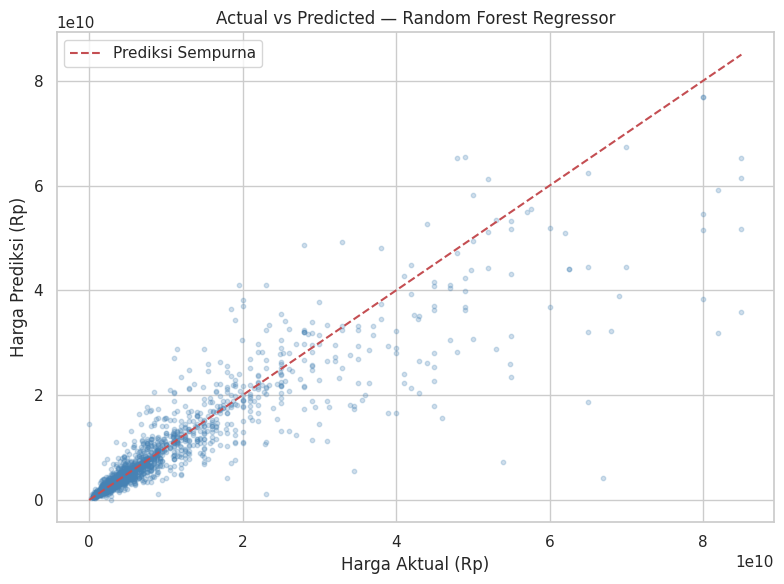

In [ ]:
# Visualisasi hasil perbandingan harga aktual dan harga prediksi
plt.figure(figsize=(8, 6))
plt.scatter(y_test_rp, y_pred_rp, alpha=0.25, s=10, color='steelblue')

# Garis ideal y = x
max_val = max(y_test_rp.max(), y_pred_rp.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Prediksi Sempurna')

plt.xlabel('Harga Aktual (Rp)')
plt.ylabel('Harga Prediksi (Rp)')
plt.title('Actual vs Predicted — Random Forest Regressor')
plt.legend()
plt.tight_layout()
plt.show()

Temuan:

- Sebagian besar titik data berada di sekitar garis diagonal (prediksi sempurna), yang menunjukkan bahwa model Random Forest mampu memprediksi harga rumah dengan cukup baik.
- Pada rentang harga rumah yang rendah hingga menengah, hasil prediksi cenderung lebih mendekati nilai aktual dibandingkan pada rentang harga yang sangat tinggi.
- Semakin tinggi harga rumah, penyebaran titik semakin lebar sehingga menunjukkan bahwa kesalahan prediksi meningkat pada properti dengan harga premium.
- Terdapat beberapa titik yang berada jauh dari garis diagonal, yang mengindikasikan adanya overestimate maupun underestimate pada sejumlah rumah dengan karakteristik tertentu.
- Secara keseluruhan, visualisasi menunjukkan bahwa model telah berhasil menangkap pola hubungan antara fitur dan harga rumah, meskipun akurasi prediksi masih menurun pada data dengan harga yang sangat tinggi.

/tmp/ipykernel_1115/1830405690.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Fitur', data=feat_imp, palette='viridis')


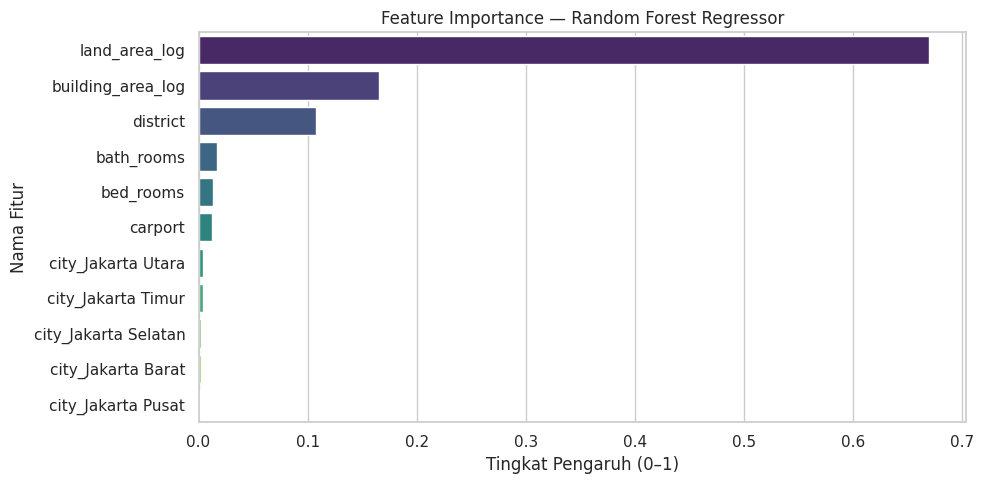


Top 5 Fitur:
            Fitur  Importance
    land_area_log    0.670135
building_area_log    0.165266
         district    0.107463
       bath_rooms    0.016658
        bed_rooms    0.013153


In [ ]:
#Visualisasi feature importance
feat_imp = pd.DataFrame({
    'Fitur'      : X.columns,
    'Importance' : rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Fitur', data=feat_imp, palette='viridis')
plt.title('Feature Importance — Random Forest Regressor')
plt.xlabel('Tingkat Pengaruh (0–1)')
plt.ylabel('Nama Fitur')
plt.tight_layout()
plt.show()

print("\nTop 5 Fitur:")
print(feat_imp.head(5).to_string(index=False))

Temuan:

- Hasil feature importance menunjukkan bahwa land_area_log merupakan fitur yang paling berpengaruh dalam memprediksi harga rumah dengan nilai importance sebesar 0,6701 (67,01%).
- Fitur building_area_log berada pada urutan kedua dengan tingkat pengaruh sebesar 16,53%, menunjukkan bahwa luas bangunan juga memiliki kontribusi yang besar terhadap harga rumah.
- Fitur district menempati urutan ketiga dengan nilai importance sebesar 10,75%, yang mengindikasikan bahwa lokasi distrik merupakan faktor penting dalam menentukan harga rumah.


In [ ]:
# =====================================================
# SIMULASI PREDIKSI HARGA RUMAH
# =====================================================

sample = pd.DataFrame([{
    'district': 'Kebayoran Baru',
    'city': 'Jakarta Selatan',
    'bed_rooms': 3,
    'bath_rooms': 2,
    'carport': 1,
    'land_area': 150,
    'building_area': 200
}])

# -----------------------------------------------------
# Transformasi log (HARUS sama seperti training)
# -----------------------------------------------------
sample['land_area_log'] = np.log1p(sample['land_area'])
sample['building_area_log'] = np.log1p(sample['building_area'])

sample.drop(columns=['land_area','building_area'], inplace=True)

# -----------------------------------------------------
# One Hot Encoding kota
# -----------------------------------------------------
sample = pd.get_dummies(sample,
                        columns=['city'],
                        drop_first=False)

# -----------------------------------------------------
# Tambahkan kolom kota yang belum ada
# -----------------------------------------------------
city_cols = [c for c in X.columns if c.startswith('city_')]

for col in city_cols:
    if col not in sample.columns:
        sample[col] = 0

# -----------------------------------------------------
# Susun kolom sebelum Target Encoding
# -----------------------------------------------------
sample = sample[[
    'district',
    'bed_rooms',
    'bath_rooms',
    'carport',
    'land_area_log',
    'building_area_log',
    'city_Jakarta Barat',
    'city_Jakarta Pusat',
    'city_Jakarta Selatan',
    'city_Jakarta Timur',
    'city_Jakarta Utara'
]]

# -----------------------------------------------------
# Target Encoding district
# -----------------------------------------------------
sample = te.transform(sample)

# -----------------------------------------------------
# Pastikan urutan kolom sama persis
# -----------------------------------------------------
sample = sample[X.columns]

# Ubah bool menjadi int jika ada
bool_cols = sample.select_dtypes(include='bool').columns
sample[bool_cols] = sample[bool_cols].astype(int)

# -----------------------------------------------------
# Prediksi
# -----------------------------------------------------
pred_log = rf_model.predict(sample)[0]

pred_price = np.expm1(pred_log)

# =====================================================
# OUTPUT
# =====================================================

print("="*55)
print("        SIMULASI PREDIKSI HARGA RUMAH")
print("="*55)
print("Lokasi         : Kebayoran Baru, Jakarta Selatan")
print("Kamar Tidur    : 3")
print("Kamar Mandi    : 2")
print("Carport        : 1")
print("Luas Tanah     : 150 m²")
print("Luas Bangunan  : 200 m²")
print("-"*55)
print(f"Estimasi Harga : Rp {pred_price:,.0f}")
print("="*55)

        SIMULASI PREDIKSI HARGA RUMAH
Lokasi         : Kebayoran Baru, Jakarta Selatan
Kamar Tidur    : 3
Kamar Mandi    : 2
Carport        : 1
Luas Tanah     : 150 m²
Luas Bangunan  : 200 m²
-------------------------------------------------------
Estimasi Harga : Rp 7,028,870,265


Temuan:

Berdasarkan simulasi prediksi, model Random Forest mengestimasi harga rumah di Kebayoran Baru, Jakarta Selatan dengan spesifikasi yang diberikan sebesar sekitar Rp7,03 miliar. Hasil ini menunjukkan bahwa model dapat digunakan sebagai alat bantu untuk memberikan estimasi awal harga rumah berdasarkan karakteristik fisik dan lokasi properti.